**1.1** Domain-mean SEB timeseries, residual, cloud cover (2stream vs raytracer)  
**1.2** SEB conditioned on cloud-root vs. cloud-free columns

In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from cass_analysis import (
    RunSet,
    load_stats_ensemble,
    conditioned_means_ensemble,
    seb_residual, bowen_ratio, evaporative_fraction, compute_z_sl,
    plot_seb_timeseries, plot_seb_residual, plot_flux_conditioned,
    FLUX_COLORS, RT_STYLE, RT_LABEL,
    rho, cp, Lv,
)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCRATCH = "/pscratch/sd/m/mpowell/CASS_LES"
EXPT    = "experiments/no_aerosols_zero_wind"      # change to switch experiment 
N_REPS  = 4
# ─────────────────────────────────────────────────────────────────────────────

rs = RunSet(EXPT, f"{SCRATCH}/{EXPT}", n_reps=N_REPS)
print(rs)

RunSet('experiments/no_aerosols_zero_wind', root=/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind)
  2stream: 4 rep(s)
  raytracer: 4 rep(s)


In [6]:
# Load stats (domain-mean timeseries + vertical profiles)
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs["2stream"])
srt_mean, srt_std = load_stats_ensemble(rs.dirs["raytracer"])

print(f"2stream:   {len(rs.dirs['2stream'])} rep(s), "
      f"t = {s2s_mean['t_local'][0]} → {s2s_mean['t_local'][-1]}")
print(f"raytracer: {len(rs.dirs['raytracer'])} rep(s), "
      f"t = {srt_mean['t_local'][0]} → {srt_mean['t_local'][-1]}")

2stream:   4 rep(s), t = 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999
raytracer: 4 rep(s), t = 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999


## 1.1  Domain-mean SEB

2stream  peak|resid|=6.4  daytime_mean|resid|=0.2 W m⁻²
raytracer  peak|resid|=11.4  daytime_mean|resid|=3.7 W m⁻²


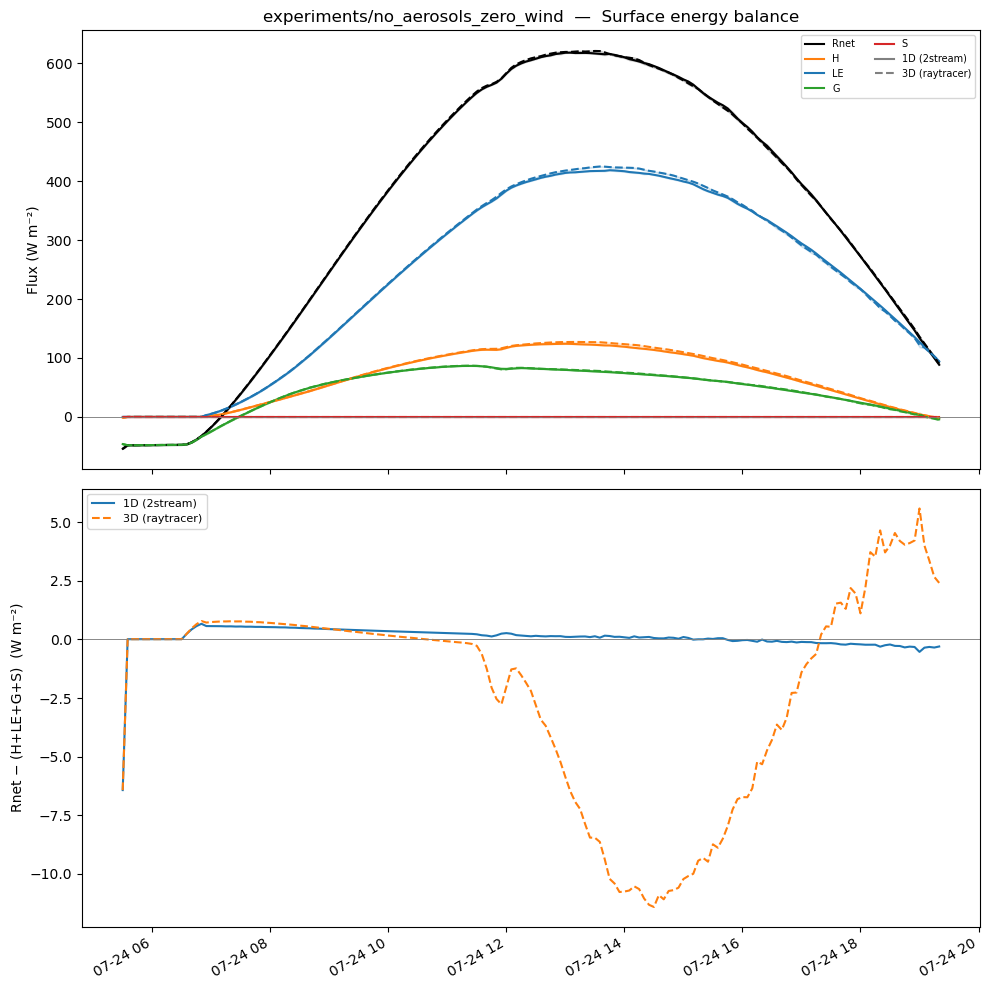

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# ── Panel 1: SEB components ──────────────────────────────────────────────────
ax = axes[0]
for rt, sm, ss in [("2stream", s2s_mean, s2s_std), ("raytracer", srt_mean, srt_std)]:
    plot_seb_timeseries(ax, sm, ss, rt_type=rt)

# Legend: flux colours + linestyles
flux_handles = [Line2D([0],[0], color=c, ls="-", label=f) for f, c in FLUX_COLORS.items()]
rt_handles   = [Line2D([0],[0], color="gray", ls=sty["ls"], label=RT_LABEL[rt])
                for rt, sty in RT_STYLE.items()]
ax.legend(handles=flux_handles + rt_handles, fontsize=7, ncol=2)
ax.set_title(f"{rs.name}  —  Surface energy balance")

# ── Panel 2: SEB residual ────────────────────────────────────────────────────
ax = axes[1]
for rt, sm in [("2stream", s2s_mean), ("raytracer", srt_mean)]:
    plot_seb_residual(ax, sm, rt_type=rt)
# Print peak residuals
for rt, sm in [("2stream", s2s_mean), ("raytracer", srt_mean)]:
    resid = seb_residual(sm)
    daytime = sm["Rnet"] > 50
    print(f"{rt}  peak|resid|={np.abs(resid).max():.1f}  "
          f"daytime_mean|resid|={np.abs(resid[daytime]).mean():.1f} W m⁻²")
ax.legend(fontsize=8)


plt.tight_layout()
plt.show()

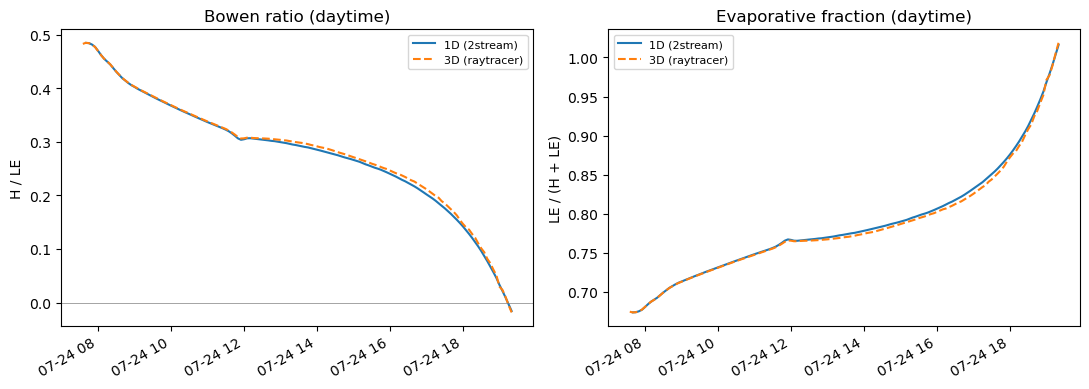

In [8]:
# Bowen ratio and evaporative fraction (daytime only)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for rt, sm in [("2stream", s2s_mean), ("raytracer", srt_mean)]:
    daytime = sm["Rnet"] > 50
    t_day   = sm["t_local"][daytime]
    sty = RT_STYLE[rt]

    br = bowen_ratio(sm)
    ef = evaporative_fraction(sm)

    axes[0].plot(t_day, br[daytime], label=RT_LABEL[rt], **sty)
    axes[1].plot(t_day, ef[daytime], label=RT_LABEL[rt], **sty)

axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_ylabel("H / LE")
axes[0].set_title("Bowen ratio (daytime)")
axes[1].set_ylabel("LE / (H + LE)")
axes[1].set_title("Evaporative fraction (daytime)")
for ax in axes:
    ax.legend(fontsize=8)
    ax.figure.autofmt_xdate()

plt.tight_layout()
plt.show()

## 1.2  SEB conditioned on cloud mask

At each timestep, columns are partitioned into **cloud-root** (`qlqi_path > 0`) and **cloud-free** (`qlqi_path = 0`).  
Conditional means of `thl_fluxbot` and `qt_fluxbot` are shown, converted to W m⁻². Also surface irradiance.

In [ ]:
import os, pickle

CACHE_DIR = Path(os.environ.get("SCRATCH", "/pscratch/sd/m/mpowell")) / "CASS_LES/analysis/seb_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _compute_cond(result):
    """Eagerly materialise all lazy DataArrays in a conditioned-means result tuple."""
    mean_dict, std_dict = result
    for d in (mean_dict, std_dict):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_dict, std_dict

def _load_or_compute_conditioned(rep_dirs, cache_name, variables, force=False):
    """Load conditioned ensemble means from pickle cache, or compute and cache."""
    cache_file = CACHE_DIR / f"{cache_name}.pkl"
    if not force and cache_file.exists():
        print(f"  [cache hit] {cache_file.name}")
        with open(cache_file, "rb") as fh:
            return pickle.load(fh)
    print(f"  [computing] {cache_name} …")
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, "wb") as fh:
        pickle.dump(result, fh)
    print(f"  [cached]    {cache_file.name}")
    return result

# Slug from EXPT path (e.g. "experiments/no_aerosols_zero_wind" → "experiments_no_aerosols_zero_wind")
_expt_slug = EXPT.replace("/", "_")

cond_2s_mean, cond_2s_std = _load_or_compute_conditioned(
    rs.dirs["2stream"],
    f"{_expt_slug}__2stream",
    variables=["thl_fluxbot", "qt_fluxbot", "sw_flux_dn"],
)
cond_rt_mean, cond_rt_std = _load_or_compute_conditioned(
    rs.dirs["raytracer"],
    f"{_expt_slug}__raytracer",
    variables=["thl_fluxbot", "qt_fluxbot", "sw_flux_sfc_rt", "sw_flux_dn"],
)
print("Done.")

/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


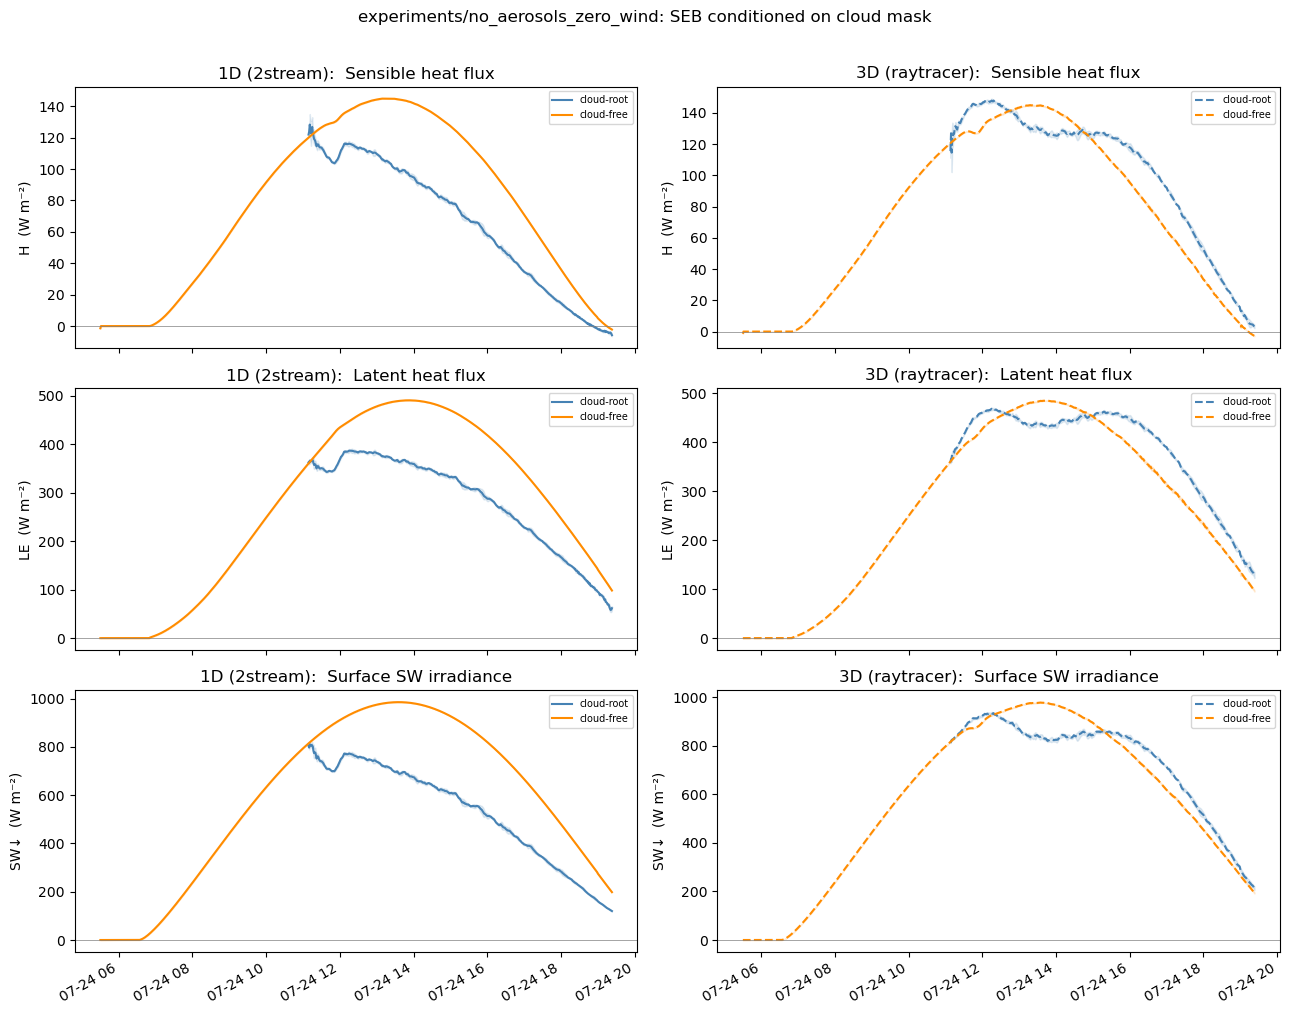

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)

H_scale  = rho * cp   # thl_fluxbot → H  [W m⁻²]
LE_scale = rho * Lv   # qt_fluxbot  → LE [W m⁻²]

for col, (rt, cm, cs) in enumerate([
    ("2stream",   cond_2s_mean, cond_2s_std),
    ("raytracer", cond_rt_mean, cond_rt_std),
]):
    t_local = cm["shaded"]["thl_fluxbot"].time.values

    # Sensible heat flux (H)
    plot_flux_conditioned(
        axes[0, col], t_local,
        cm["shaded"]["thl_fluxbot"], cm["unshaded"]["thl_fluxbot"],
        cs["shaded"].get("thl_fluxbot"), cs["unshaded"].get("thl_fluxbot"),
        rt_type=rt, ylabel="H  (W m⁻²)", scale=H_scale,
    )
    axes[0, col].set_title(f"{RT_LABEL[rt]}:  Sensible heat flux")

    # Latent heat flux (LE)
    plot_flux_conditioned(
        axes[1, col], t_local,
        cm["shaded"]["qt_fluxbot"], cm["unshaded"]["qt_fluxbot"],
        cs["shaded"].get("qt_fluxbot"), cs["unshaded"].get("qt_fluxbot"),
        rt_type=rt, ylabel="LE  (W m⁻²)", scale=LE_scale,
    )
    axes[1, col].set_title(f"{RT_LABEL[rt]}:  Latent heat flux")

    # SW irradiance
    sw_key = "sw_flux_sfc_rt" if "sw_flux_sfc_rt" in cm["shaded"] else "sw_flux_dn"
    plot_flux_conditioned(
        axes[2, col], t_local,
        cm["shaded"][sw_key], cm["unshaded"][sw_key],
        cs["shaded"].get(sw_key), cs["unshaded"].get(sw_key),
        rt_type=rt, ylabel="SW↓  (W m⁻²)", scale=1.0,
    )
    axes[2, col].set_title(f"{RT_LABEL[rt]}:  Surface SW irradiance")

for ax in axes.flat:
    ax.legend(fontsize=7)

plt.suptitle(f"{rs.name}: SEB conditioned on cloud mask", y=1.01)
plt.tight_layout()
plt.show()